<a href="https://colab.research.google.com/github/m00n07/mineria_de_datos/blob/main/3P/Proyecto/Proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install resampy --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 22.6 MB/s eta 0:00:00


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Iniciando extracción de MFCC con limpieza de silencios...
Cargando 2 archivos de: /content/drive/MyDrive/ProyectoAudio/apagar
Directorio encontrado: /content/drive/MyDrive/ProyectoAudio/apagar (2 archivos)
Cargando 2 archivos de: /content/drive/MyDrive/ProyectoAudio/encender
Directorio encontrado: /content/drive/MyDrive/ProyectoAudio/encender (2 archivos)

✅ Procesamiento terminado. Muestras totales: 4

Entrenando el modelo...
Epoch 1/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0000e+00 - loss: 0.8927 - val_accuracy: 0.0000e+00 - val_loss: 0.7512
Epoch 2/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 1.0000 - loss: 0.5280 - val_accuracy: 0.0000e+00 - val_loss: 0.7806
Epoch 3/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 1.0000 - loss: 0.2881 - val_accuracy: 0.0000e+00 - val_loss: 0.7582
Epoch 4/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step -

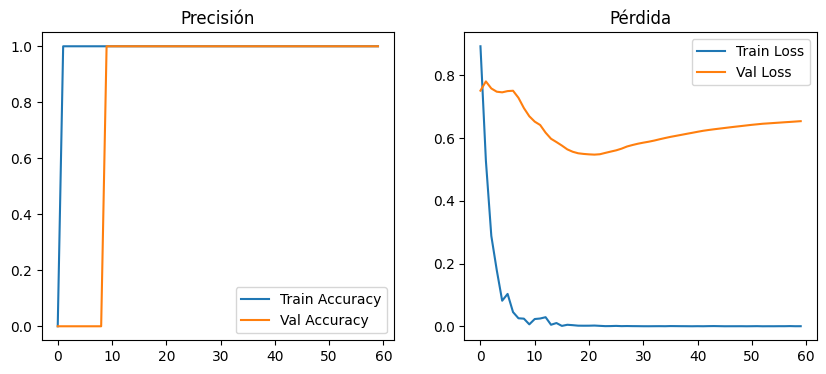


Analizando audio de prueba: /content/drive/MyDrive/ProyectoAudio/apagar/apagar.wav

Analizando: /content/drive/MyDrive/ProyectoAudio/apagar/apagar.wav
>>> RESULTADO: [ LUZ APAGADA ] (Confianza: 0.8036)

Analizando audio de prueba: /content/drive/MyDrive/ProyectoAudio/encender/encender.wav

Analizando: /content/drive/MyDrive/ProyectoAudio/encender/encender.wav
>>> RESULTADO: [ LUZ ENCENDIDA ] (Confianza: 0.5078)

Analizando audio de prueba: /content/drive/MyDrive/ProyectoAudio/apagar/apagar2.wav

Analizando: /content/drive/MyDrive/ProyectoAudio/apagar/apagar2.wav
>>> RESULTADO: [ LUZ APAGADA ] (Confianza: 0.5200)

Analizando audio de prueba: /content/drive/MyDrive/ProyectoAudio/encender/encender2.wav

Analizando: /content/drive/MyDrive/ProyectoAudio/encender/encender2.wav
>>> RESULTADO: [ LUZ ENCENDIDA ] (Confianza: 0.6007)


In [13]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from google.colab import drive

# --- FASE 1: MONTAJE Y CONFIGURACIÓN ---
drive.mount('/content/drive')

# Rutas exactas confirmadas por el usuario
PATH_ENCENDER = '/content/drive/MyDrive/ProyectoAudio/encender'
PATH_APAGAR = '/content/drive/MyDrive/ProyectoAudio/apagar'

# --- FASE 2: PROCESAMIENTO DE AUDIO (MFCC) ---
def extract_features(file_path, max_pad_len=40):
    try:
        # Carga del audio (requiere resampy instalado)
        audio, sr = librosa.load(file_path, res_type='kaiser_fast')

        # CAMBIO 1: Eliminación de silencios al inicio y al final
        audio, _ = librosa.effects.trim(audio)

        # Extracción de características
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

        # Ajuste de tamaño (Padding/Truncado) para obtener 40x40
        if (mfccs.shape[1] < max_pad_len):
            pad_width = max_pad_len - mfccs.shape[1]
            mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfccs = mfccs[:, :max_pad_len]
        return mfccs
    except Exception as e:
        print(f"Error procesando {file_path}: {e}")
        return None

X, y = [], []

# Diccionario para automatizar la carga
carpetas = {0: PATH_APAGAR, 1: PATH_ENCENDER}

# print("Iniciando extracción de MFCC...")
# CAMBIO
print("Iniciando extracción de MFCC con limpieza de silencios...")
# FIN CAMBIO
for etiqueta, ruta in carpetas.items():
    if os.path.exists(ruta):
        # Buscamos archivos .wav (ignorando mayúsculas/minúsculas)
        archivos = [f for f in os.listdir(ruta) if f.lower().endswith('.wav')]
        # CAMBIO
        print(f"Cargando {len(archivos)} archivos de: {ruta}")
        # FIN CAMBIO
        print(f"Directorio encontrado: {ruta} ({len(archivos)} archivos)")

        for p in archivos:
            data = extract_features(os.path.join(ruta, p))
            if data is not None:
                X.append(data)
                y.append(etiqueta)
    else:
        print(f"❌ ERROR: No se encontró la ruta: {ruta}")

# Conversión a NumPy y Normalización
X = np.array(X)
y = np.array(y)

if len(X) > 0:

    # CAMBIO
    # Guardamos los valores globales para la normalización posterior
    X_min = np.min(X)
    X_max = np.max(X)
    X = (X - X_min) / (X_max - X_min)
    # FIN CAMBIO

    # Normalización entre 0 y 1
    # X = (X - np.min(X)) / (np.max(X) - np.min(X))

    # División de datos (80% entrenamiento, 20% validación)
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"\n✅ Procesamiento terminado. Muestras totales: {len(X)}")
else:
    print("\n❌ Error Crítico: No se cargaron datos. Verifica tus carpetas en Drive.")

# --- FASE 3: MODELO Y ENTRENAMIENTO ---
if len(X) > 0:
    """model = models.Sequential([
        layers.Input(shape=(40, 40)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid') # Salida binaria: 0 (Apagar) o 1 (Encender)
    ])"""
    # CAMBIO
    model = models.Sequential([
        layers.Input(shape=(40, 40)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'), # Aumentamos neuronas
        layers.BatchNormalization(),          # Ayuda a estabilizar el aprendizaje
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),                  # Bajamos un poco el dropout
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    # FIN CAMBIO

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    print("\nEntrenando el modelo...")
    # history = model.fit(X_train, y_train, epochs=50, batch_size=16,
                        # validation_data=(X_val, y_val), verbose=1)
    # CAMBIO
    history = model.fit(X_train, y_train, epochs=60, batch_size=16,
                        validation_data=(X_val, y_val), verbose=1)
    # FIN CAMBIO

    # Gráficas de Rendimiento
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.legend(); plt.title('Precisión')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend(); plt.title('Pérdida')
    plt.show()

# --- FASE 4: SIMULACIÓN Y PRUEBA (VOZ DEL PROFESOR) ---
def predecir_luz(ruta_audio):
    print(f"\nAnalizando audio de prueba: {ruta_audio}")
    nuevo_mfcc = extract_features(ruta_audio)
    if nuevo_mfcc is not None:
        # Normalización (usando los mismos parámetros)
        # nuevo_mfcc = (nuevo_mfcc - np.min(nuevo_mfcc)) / (np.max(nuevo_mfcc) - np.min(nuevo_mfcc))
        # CAMBIO 3: Normalización usando los parámetros globales del entrenamiento
        nuevo_mfcc = (nuevo_mfcc - X_min) / (X_max - X_min)
        # FIN CAMBIO
        nuevo_mfcc = nuevo_mfcc.reshape(1, 40, 40)

        prediccion = model.predict(nuevo_mfcc, verbose=0)
        # CAMBIO
        confianza = prediccion[0][0]

        print(f"\nAnalizando: {ruta_audio}")
        # FIN CAMBIO

        """
        if prediccion[0][0] >= 0.5:
            print(f">>> RESULTADO: [ LUZ ENCENDIDA ] (Confianza: {prediccion[0][0]:.4f})")
        else:
            print(f">>> RESULTADO: [ LUZ APAGADA ] (Confianza: {1-prediccion[0][0]:.4f})")"""
        # CAMBIO
        if confianza >= 0.5:
            print(f">>> RESULTADO: [ LUZ ENCENDIDA ] (Confianza: {confianza:.4f})")
        else:
            print(f">>> RESULTADO: [ LUZ APAGADA ] (Confianza: {1 - confianza:.4f})")
        # FIN CAMBIO
    else:
        print("No se pudo procesar el audio de prueba.")


# --- EJEMPLOS DE PRUEBA ---
predecir_luz('/content/drive/MyDrive/ProyectoAudio/apagar/apagar.wav')
predecir_luz('/content/drive/MyDrive/ProyectoAudio/encender/encender.wav')
predecir_luz('/content/drive/MyDrive/ProyectoAudio/apagar/apagar2.wav')
predecir_luz('/content/drive/MyDrive/ProyectoAudio/encender/encender2.wav')


# Para probar con la voz del profesor, coloca el archivo en Drive y cambia la ruta:
# 1. Definir la ruta exacta
# ruta_profesor = '/content/drive/MyDrive/ProyectoAudio/prueba_profe.wav'

# 2. Llamar a la función de predicción
# predecir_luz(ruta_profesor)

In [ ]:
""" import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from google.colab import drive

# Montar Drive
drive.mount('/content/drive')

# Rutas de tus carpetas
BASE_PATH = '/content/drive/MyDrive/ProyectoAudio'
CATEGORIAS = ['apagar', 'encender'] """

" import os\nimport librosa\nimport numpy as np\nimport matplotlib.pyplot as plt\nimport tensorflow as tf\nfrom tensorflow.keras import layers, models\nfrom sklearn.model_selection import train_test_split\nfrom google.colab import drive\n\n# Montar Drive\ndrive.mount('/content/drive')\n\n# Rutas de tus carpetas\nBASE_PATH = '/content/drive/MyDrive/ProyectoAudio'\nCATEGORIAS = ['apagar', 'encender'] "

In [ ]:
""" # Función corregida
def extract_features(file_path, max_pad_len=40):
    try:
        # Cargamos el audio. Si da error de resampy, asegúrate de haber corrido !pip install resampy
        audio, sr = librosa.load(file_path, res_type='kaiser_fast')
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

        if (mfccs.shape[1] < max_pad_len):
            pad_width = max_pad_len - mfccs.shape[1]
            mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfccs = mfccs[:, :max_pad_len]
        return mfccs
    except Exception as e:
        print(f"Error procesando {file_path}: {e}")
        return None

X, y = [], []

# Procesar carpetas
for label, cat in enumerate(CATEGORIAS):
    ruta_cat = os.path.join(BASE_PATH, cat)
    if not os.path.exists(ruta_cat):
        print(f"⚠️ ¡Atención! La carpeta {cat} no existe en la ruta especificada.")
        continue

    # archivos = [f for f in os.listdir(ruta_cat) if f.endswith('.wav')]
    archivos = [f for f in os.listdir(ruta_cat) if f.lower().endswith('.wav')]
    print(f"Procesando {len(archivos)} audios de la categoría: {cat}...")

    for archivo in archivos:
        data = extract_features(os.path.join(ruta_cat, archivo))
        if data is not None:
            X.append(data)
            y.append(label)

# Convertir a numpy
X = np.array(X)
y = np.array(y)

# --- VERIFICACIÓN DE SEGURIDAD ---
if len(X) == 0:
    print("❌ ERROR CRÍTICO: No se cargó ningún audio. Revisa las rutas en Drive.")
else:
    # Normalización (Solo si X tiene datos)
    X = (X - np.min(X)) / (np.max(X) - np.min(X))
    print(f"✅ Procesamiento completado con éxito. Total de muestras: {len(X)}") """

' # Función corregida\ndef extract_features(file_path, max_pad_len=40):\n    try:\n        # Cargamos el audio. Si da error de resampy, asegúrate de haber corrido !pip install resampy\n        audio, sr = librosa.load(file_path, res_type=\'kaiser_fast\')\n        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)\n        \n        if (mfccs.shape[1] < max_pad_len):\n            pad_width = max_pad_len - mfccs.shape[1]\n            mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode=\'constant\')\n        else:\n            mfccs = mfccs[:, :max_pad_len]\n        return mfccs\n    except Exception as e:\n        print(f"Error procesando {file_path}: {e}")\n        return None\n\nX, y = [], []\n\n# Procesar carpetas\nfor label, cat in enumerate(CATEGORIAS):\n    ruta_cat = os.path.join(BASE_PATH, cat)\n    if not os.path.exists(ruta_cat):\n        print(f"⚠️ ¡Atención! La carpeta {cat} no existe en la ruta especificada.")\n        continue\n        \n    # archivos = [f 

In [ ]:
!ls "/content/drive/MyDrive/ProyectoAudio"

apagar	encender


In [ ]:
""" import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Definición del modelo con la nueva sintaxis de Keras 3
model = models.Sequential([
    # En lugar de input_shape en Flatten, usamos una capa Input
    layers.Input(shape=(40, 40)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# 2. Compilación
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 3. Entrenamiento
# IMPORTANTE: Asegúrate de haber corrido la celda anterior donde se definen X_train y y_train
try:
    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=16,
        validation_data=(X_val, y_val)
    )

    # 4. Gráfica de resultados
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Validación')
    plt.title('Precisión (Accuracy)')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Entrenamiento')
    plt.plot(history.history['val_loss'], label='Validación')
    plt.title('Pérdida (Loss)')
    plt.legend()

    plt.show()

except NameError:
    print("❌ ERROR: No se encontraron las variables X_train o y_train.")
    print("Por favor, ejecuta primero la celda de 'Procesamiento de Audios' para cargar los datos.") """

' import tensorflow as tf\nfrom tensorflow.keras import layers, models\n\n# 1. Definición del modelo con la nueva sintaxis de Keras 3\nmodel = models.Sequential([\n    # En lugar de input_shape en Flatten, usamos una capa Input\n    layers.Input(shape=(40, 40)), \n    layers.Flatten(),\n    layers.Dense(128, activation=\'relu\'),\n    layers.Dropout(0.3),\n    layers.Dense(64, activation=\'relu\'),\n    layers.Dense(1, activation=\'sigmoid\')\n])\n\n# 2. Compilación\nmodel.compile(\n    optimizer=\'adam\', \n    loss=\'binary_crossentropy\', \n    metrics=[\'accuracy\']\n)\n\n# 3. Entrenamiento\n# IMPORTANTE: Asegúrate de haber corrido la celda anterior donde se definen X_train y y_train\ntry:\n    history = model.fit(\n        X_train, y_train, \n        epochs=50, \n        batch_size=16, \n        validation_data=(X_val, y_val)\n    )\n\n    # 4. Gráfica de resultados\n    plt.figure(figsize=(12, 4))\n\n    plt.subplot(1, 2, 1)\n    plt.plot(history.history[\'accuracy\'], label=\'En

In [ ]:
""" def test_audio(ruta_prueba):
    feat = extract_features(ruta_prueba)
    if feat is not None:
        feat = feat.reshape(1, 40, 40)
        pred = model.predict(feat)
        print(f"Predicción: {'ENCENDER' if pred > 0.5 else 'APAGAR'} ({pred[0][0]:.2f})")

# Descomenta para probar un audio específico:
# test_audio('/content/drive/MyDrive/ProyectoAudio/voz_profesor.wav') """

' def test_audio(ruta_prueba):\n    feat = extract_features(ruta_prueba)\n    if feat is not None:\n        feat = feat.reshape(1, 40, 40)\n        pred = model.predict(feat)\n        print(f"Predicción: {\'ENCENDER\' if pred > 0.5 else \'APAGAR\'} ({pred[0][0]:.2f})")\n\n# Descomenta para probar un audio específico:\n# test_audio(\'/content/drive/MyDrive/ProyectoAudio/voz_profesor.wav\') '